# micrograd demo

In [1]:
from micrograd import Weight, NeuralNet, zero_grad

(200, 2) (200,)


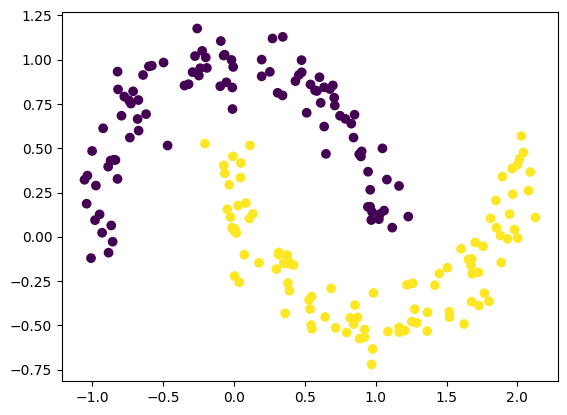

In [251]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt


X, y = make_moons(n_samples=200, noise=0.1, random_state=1)
print(X.shape, y.shape)
plt.figure()
plt.scatter(X[:,0], X[:,1], c=y)

# Setting 1: MSE + batch training

In [264]:
# Model
m = NeuralNet(2, [2, 3, 1], ['relu', 'relu', 'sigmoid'])
print(len(m.parameters()), 'params')

19 params


In [186]:
# Loss
def MSE(y_pred : list, y_true : list):
    temp = list(zip([i[0] for i in y_pred], y_true))
    loss = sum([(y_hat - y)**2 for (y_hat, y) in temp]) / len(y_true)
    return loss

In [258]:
def train(model, X, y, loss_function, epochs, learning_rate):
    for i in range(epochs):
        # forward pass
        y_pred = [model(x) for x in X]
        # Calculate accuracy
        label = [(o[0].data >= 0.5) for o in y_pred]
        temp = [a == b for (a, b) in zip(label, y)]
        accuracy = sum(temp) / len(temp)
        # Calculate loss
        loss = loss_function(y_pred, y)
        # backprop
        zero_grad(loss)
        loss.backward()
        # gradient descent
        lr = learning_rate - 0.9*i/epochs  # decay
        for p in model.parameters():
            p.data = p.data - lr * p.grad
        # log
        if i % 10 == 0:
            print(f"step {i}: loss {loss.data} | accuracy {accuracy*100:.2f}%")

In [265]:
import time

start = time.perf_counter()
train(m, X, y, MSE, 100, 1.0)
print(time.perf_counter() - start, 'seconds')

step 0: loss 0.45415907706127023 | accuracy 50.00%
step 10: loss 0.2443619910130656 | accuracy 50.00%
step 20: loss 0.21394732153584325 | accuracy 62.50%
step 30: loss 0.18802617318026632 | accuracy 67.00%
step 40: loss 0.16780974989613623 | accuracy 76.00%
step 50: loss 0.15212021515192495 | accuracy 79.00%
step 60: loss 0.14026221661566823 | accuracy 80.50%
step 70: loss 0.13030542490555072 | accuracy 81.50%
step 80: loss 0.12286684681944006 | accuracy 83.50%
step 90: loss 0.11798727789515775 | accuracy 84.00%
59.762371100019664 seconds


In [266]:
y_pred = [m(x) for x in X]
label = [(i[0].data >= 0.5) for i in y_pred]

Text(0.5, 1.0, 'Prediction')

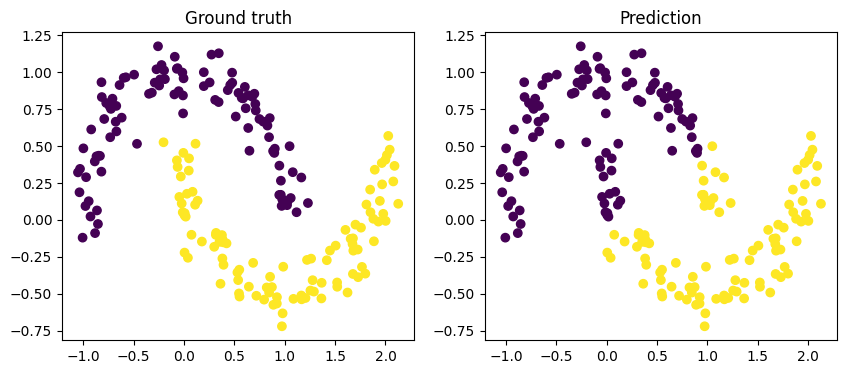

In [267]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X[:,0], X[:,1], c=y)
ax1.set_title("Ground truth")

ax2.scatter(X[:,0], X[:,1], c=label)
ax2.set_title("Prediction")

# Setting 2: BCE + batch training

In [317]:
def BCE(y_pred: list, y_true: list, _eps=1e-7):
    temp = list(zip([i[0] for i in y_pred], y_true))
    loss = 0.0
    for (y_hat, y) in temp:
        if y_hat.data <= 0.0:
            y_hat.data = _eps
        elif y_hat.data >= 1.0:
            y_hat.data = 1.0 - _eps
        
        loss += y * y_hat.log() + (1 - y) * (1 - y_hat).log()
    
    loss *= -1 / len(y_true)
    return loss

In [269]:
# Model
m = NeuralNet(2, [2, 3, 1], ['relu', 'relu', 'sigmoid'])
print(len(m.parameters()), 'params')

19 params


In [270]:
import time

start = time.perf_counter()
train(m, X, y, BCE, 100, 1.0)
print(time.perf_counter() - start, 'seconds')

step 0: loss 1.2110778111406184 | accuracy 50.00%
step 10: loss 0.620258198380886 | accuracy 73.00%
step 20: loss 0.3424513761846751 | accuracy 83.50%
step 30: loss 0.27198699385039543 | accuracy 88.00%
step 40: loss 0.2644378293234438 | accuracy 87.50%
step 50: loss 0.263501627255733 | accuracy 87.00%
step 60: loss 0.26322264308990456 | accuracy 87.00%
step 70: loss 0.2630914512386924 | accuracy 87.00%
step 80: loss 0.2630233125001064 | accuracy 87.00%
step 90: loss 0.26298014595070063 | accuracy 87.00%
82.5161183999735 seconds


In [271]:
y_pred = [m(x) for x in X]
label = [(i[0].data >= 0.5) for i in y_pred]

Text(0.5, 1.0, 'Prediction')

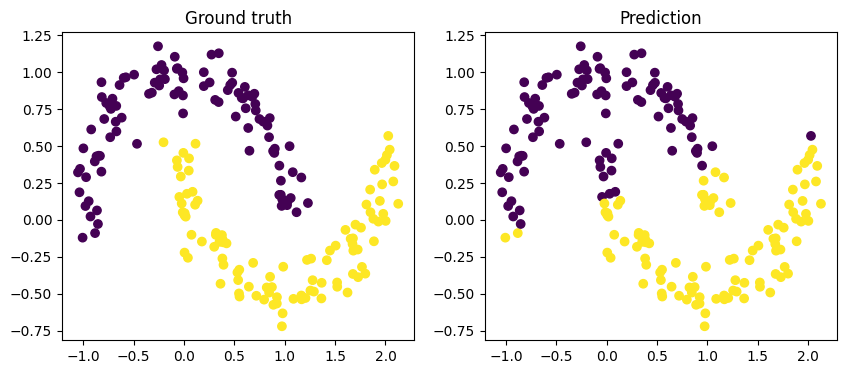

In [272]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X[:,0], X[:,1], c=y)
ax1.set_title("Ground truth")

ax2.scatter(X[:,0], X[:,1], c=label)
ax2.set_title("Prediction")

# Setting 3: BCE + mini batch training

In [385]:
import random

def train_minibatch(model, X, y, loss_function, batch_size, epochs, learning_rate, _lambda = 0.0):
    for i in range(epochs):
        # sampling
        assert batch_size <= len(X), 'batch size too large'
        indices = random.sample(range(len(X)), k=batch_size)
        X_batch = X[indices]
        # forward pass
        y_pred = [model(x) for x in X_batch]
        # Calculate loss
        loss = loss_function(y_pred, y[indices])
        L2_loss = 0.0 if not _lambda else _lambda * sum([p**2 for p in model.parameters()])
        total_loss = loss + L2_loss
        # backprop
        zero_grad(loss)
        loss.backward()
        # gradient descent
        lr = learning_rate - 0.9*i/epochs  # decay
        for p in model.parameters():
            p.data = p.data - lr * p.grad
        # log
        if i % 20 == 0:
            y_pred = [model(x) for x in X]
            label = [(i[0].data >= 0.5) for i in y_pred]
            temp = [a == b for (a, b) in zip(label, y)]
            accuracy = sum(temp) / len(temp)
            print(f"step {i}: batch loss {total_loss.data} | accuracy {accuracy*100:.2f}%")

In [388]:
# Model
m = NeuralNet(2, [2, 3, 1], ['relu', 'relu', 'sigmoid'])
print(len(m.parameters()), 'params')

19 params


In [389]:
import time

start = time.perf_counter()
train_minibatch(m, X, y, BCE, 50, 300, 1.0)
print(time.perf_counter() - start, 'seconds')

step 0: batch loss 1.2164976885744314 | accuracy 50.00%
step 20: batch loss 0.24446508824000465 | accuracy 84.50%
step 40: batch loss 0.23500138761811967 | accuracy 86.50%
step 60: batch loss 0.2827245000434812 | accuracy 87.50%
step 80: batch loss 0.2823598639040856 | accuracy 85.00%
step 100: batch loss 0.29044784231085774 | accuracy 87.00%
step 120: batch loss 0.20652299458270562 | accuracy 87.50%
step 140: batch loss 0.19535068574520986 | accuracy 87.50%
step 160: batch loss 0.2971621654970328 | accuracy 88.00%
step 180: batch loss 0.1700198095925023 | accuracy 87.00%
step 200: batch loss 0.15591269770563984 | accuracy 87.00%
step 220: batch loss 0.3007382144565211 | accuracy 87.50%
step 240: batch loss 0.3244978884903121 | accuracy 86.50%
step 260: batch loss 0.21715018688399362 | accuracy 88.00%
step 280: batch loss 0.17887598254623746 | accuracy 87.00%
23.555675600015093 seconds


In [390]:
y_pred = [m(x) for x in X]
label = [(i[0].data >= 0.5) for i in y_pred]
temp = [a == b for (a, b) in zip(label, y)]
accuracy = sum(temp) / len(temp)
accuracy

np.float64(0.87)

Text(0.5, 1.0, 'Prediction')

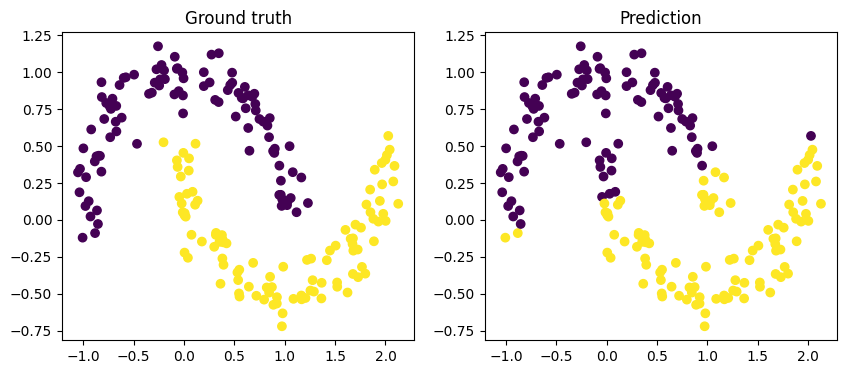

In [391]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X[:,0], X[:,1], c=y)
ax1.set_title("Ground truth")

ax2.scatter(X[:,0], X[:,1], c=label)
ax2.set_title("Prediction")

# Setting 4: BCE + mini batch training + L2 regularization

In [392]:
# Model
m = NeuralNet(2, [2, 3, 1], ['relu', 'relu', 'sigmoid'])
print(len(m.parameters()), 'params')

19 params


In [393]:
import time

start = time.perf_counter()
train_minibatch(m, X, y, BCE, 50, 300, 1.0, 1e-4)
print(time.perf_counter() - start, 'seconds')

step 0: batch loss 1.3869084546632817 | accuracy 50.00%
step 20: batch loss 0.5063428207275703 | accuracy 83.50%
step 40: batch loss 0.3386317193246269 | accuracy 86.00%
step 60: batch loss 0.2814427730266468 | accuracy 87.50%
step 80: batch loss 0.44578326072127833 | accuracy 89.50%
step 100: batch loss 0.4421247811746882 | accuracy 85.50%
step 120: batch loss 0.2680008664624578 | accuracy 88.00%
step 140: batch loss 0.4965268498005572 | accuracy 89.00%
step 160: batch loss 0.22215032409210542 | accuracy 89.00%
step 180: batch loss 0.18031537568355285 | accuracy 89.50%
step 200: batch loss 0.20514045758640406 | accuracy 90.50%
step 220: batch loss 0.26327260116593854 | accuracy 91.00%
step 240: batch loss 0.15595319849903275 | accuracy 91.50%
step 260: batch loss 0.16149030940514766 | accuracy 92.00%
step 280: batch loss 0.14693698971256544 | accuracy 92.50%
22.601487900014035 seconds


In [394]:
y_pred = [m(x) for x in X]
label = [(i[0].data >= 0.5) for i in y_pred]
temp = [a == b for (a, b) in zip(label, y)]
accuracy = sum(temp) / len(temp)
accuracy

np.float64(0.92)

Text(0.5, 1.0, 'Prediction')

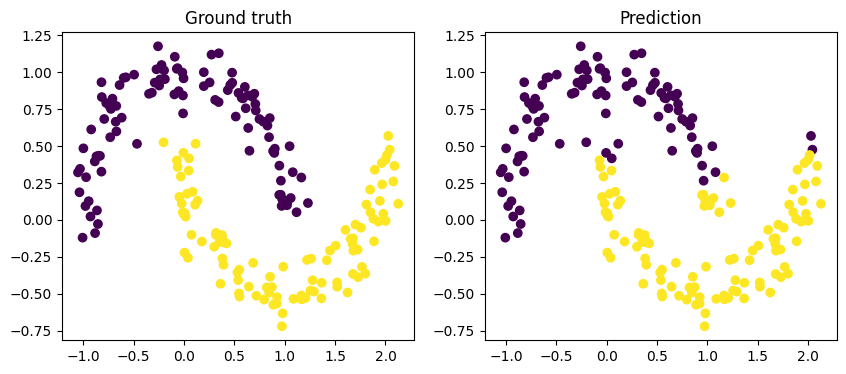

In [395]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X[:,0], X[:,1], c=y)
ax1.set_title("Ground truth")

ax2.scatter(X[:,0], X[:,1], c=label)
ax2.set_title("Prediction")

# Setting 5: Bigger model + BCE + mini batch training + L2 regularization

In [404]:
# Model
m = NeuralNet(2, [3, 3, 3, 1], ['relu', 'relu', 'relu', 'sigmoid'])
print(len(m.parameters()), 'params')

37 params


In [405]:
import time

start = time.perf_counter()
train_minibatch(m, X, y, BCE, 50, 300, 1.0, 1e-4)
print(time.perf_counter() - start, 'seconds')

step 0: batch loss 3.319594018802906 | accuracy 50.00%
step 20: batch loss 0.4976828567555238 | accuracy 79.50%
step 40: batch loss 0.5236690601428584 | accuracy 83.00%
step 60: batch loss 1.012867205042236 | accuracy 84.00%
step 80: batch loss 0.27818677112118306 | accuracy 88.00%
step 100: batch loss 0.3705618672502926 | accuracy 89.50%
step 120: batch loss 0.24725334991951123 | accuracy 93.00%
step 140: batch loss 0.11902642095932722 | accuracy 97.00%
step 160: batch loss 0.06947017443448328 | accuracy 99.00%
step 180: batch loss 0.05775729864124727 | accuracy 100.00%
step 200: batch loss 0.04432393160790251 | accuracy 100.00%
step 220: batch loss 0.048045048286966985 | accuracy 100.00%
step 240: batch loss 0.040623463531557956 | accuracy 100.00%
step 260: batch loss 0.033385673360781395 | accuracy 100.00%
step 280: batch loss 0.028827385174833294 | accuracy 100.00%
54.09811150000314 seconds


In [406]:
y_pred = [m(x) for x in X]
label = [(i[0].data >= 0.5) for i in y_pred]
temp = [a == b for (a, b) in zip(label, y)]
accuracy = sum(temp) / len(temp)
accuracy

np.float64(1.0)

Text(0.5, 1.0, 'Prediction')

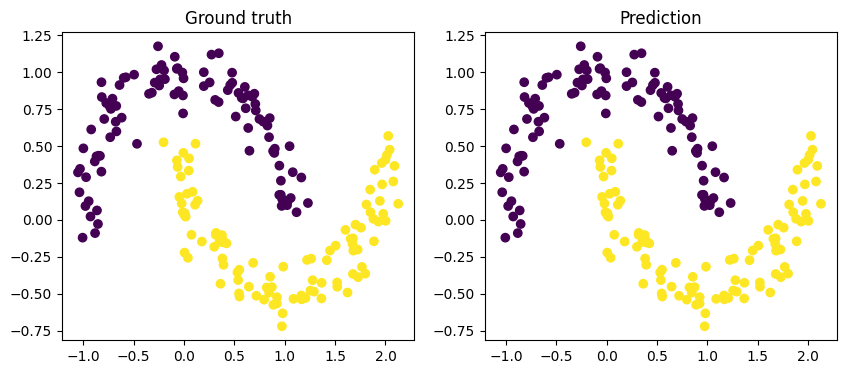

In [407]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X[:,0], X[:,1], c=y)
ax1.set_title("Ground truth")

ax2.scatter(X[:,0], X[:,1], c=label)
ax2.set_title("Prediction")

# Ending words: Bigger models != Better models. I don't show the failure cases here. But the 3-layer MLP (2,3,1) is pretty good. Some failure cases include (3,6,1), (4,4,1), (8,8,1). So we should go deeper instead of wider in this case. One reason could be we only have 2 input features. So having wider layers only creates extra relationships between those 2. In contrast, having deeper layer allows for reasoning.